# Lead Scraping & Data Enrichment Pipeline

**Source:**   `company_directory.html` — local B2B directory (30 company cards)  
**Output:**   `leads_enriched.csv` — structured, enriched lead list ready for outreach  
**Tools:**    Python · requests · BeautifulSoup · pandas

---

### What this notebook demonstrates

| Step | Task |
|---|---|
| 1 | Fetch page with `requests`, parse HTML with `BeautifulSoup` |
| 2 | Extract structured fields from each company card |
| 3 | Build a clean DataFrame from raw scraped records |
| 4 | Enrich: company tier, priority score, email validation, domain age proxy |
| 5 | Filter & rank leads by target criteria |
| 6 | Export final lead list to CSV |

> **Note:** This notebook runs against a local HTML file.
> In production, replace the `SOURCE` path with any live URL —
> the parsing and enrichment logic is identical.

## 1. Setup

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# ── scraper config ──────────────────────────────────────────────────────────
SOURCE      = 'company_directory.html'   # swap for a live URL in production
REQUEST_DELAY = 1.5                       # seconds between pages (polite scraping)
HEADERS = {
    'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 (KHTML, like Gecko) '
                   'Chrome/124.0 Safari/537.36'),
    'Accept-Language': 'en-US,en;q=0.9',
}

print('Libraries loaded. Source:', SOURCE)

Libraries loaded. Source: company_directory.html


## 2. Fetch & Parse HTML

In [2]:
def fetch_page(source: str) -> BeautifulSoup:
    """
    Fetch a page from a URL or local file.
    For a live URL, replace the local-file branch with requests.get().
    """
    if source.startswith('http'):
        resp = requests.get(source, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        html = resp.text
        time.sleep(REQUEST_DELAY)  # be polite
    else:
        html = Path(source).read_text(encoding='utf-8')

    soup = BeautifulSoup(html, 'lxml')
    return soup

soup = fetch_page(SOURCE)

# quick sanity check
title       = soup.find(id='directory-title').get_text(strip=True)
description = soup.find(id='directory-description').get_text(strip=True)
total       = soup.find(id='total-count').get_text(strip=True)

print('Page title :', title)
print('Description:', description)
print('Reported   :', total)
print('Cards found:', len(soup.select('div.company-card')))

Page title : B2B Tech Company Directory
Description: Curated list of technology companies actively hiring vendors and agencies
Reported   : 30 companies listed
Cards found: 30


## 3. Extract Data from Each Company Card

In [3]:
def parse_card(card) -> dict:
    """
    Extract all fields from a single .company-card div.
    Returns a flat dict — missing fields default to None.
    """
    def text(selector):
        el = card.select_one(selector)
        return el.get_text(strip=True) if el else None

    website_el = card.select_one('a.website')

    return {
        'company_name'   : text('.company-name'),
        'industry'       : text('.industry'),
        'location'       : text('.location'),
        'employees'      : text('.employees'),
        'website'        : website_el['href'] if website_el else None,
        'domain'         : text('a.website'),
        'contact_name'   : text('.contact-name'),
        'contact_title'  : text('.contact-title'),
        'contact_email'  : text('.contact-email'),
    }

cards  = soup.select('div.company-card')
records = [parse_card(c) for c in cards]

df = pd.DataFrame(records)
print(f'Extracted {len(df)} records')
df.head(5)

Extracted 30 records


,company_name,industry,location,employees,website,domain,contact_name,contact_title,contact_email
0,Nexova Technologies,SaaS,"San Francisco, CA",51-200 employees,https://nexova.io,nexova.io,Sarah Chen,Head of Marketing,sarah.chen@nexova.io
1,BlueRidge Analytics,Data & Analytics,"Austin, TX",11-50 employees,https://blueridge.ai,blueridge.ai,Mark Thompson,CEO,mark.thompson@blueridge.ai
2,Fortis Cloud,Cloud Services,"Seattle, WA",201-500 employees,https://fortiscloud.com,fortiscloud.com,Amanda Reyes,VP Sales,amanda.reyes@fortiscloud.com
3,Greenpath Consulting,Consulting,"New York, NY",11-50 employees,https://greenpath.co,greenpath.co,Daniel Park,Managing Partner,daniel.park@greenpath.co
4,Luminary Media,Digital Agency,"Los Angeles, CA",11-50 employees,https://luminarymedia.com,luminarymedia.com,Jessica Moore,Founder,jessica.moore@luminarymedia.com


In [4]:
# ── data quality check right after extraction ───────────────────────────────
print('Nulls per field:')
print(df.isnull().sum().to_string())
print(f'\nTotal fields: {df.shape[0] * df.shape[1]}')
print(f'Null fields : {df.isnull().sum().sum()}')
print(f'Completeness: {(1 - df.isnull().mean().mean())*100:.1f}%')

Nulls per field:
company_name     0
industry         0
location         0
employees        0
website          0
domain           0
contact_name     0
contact_title    0
contact_email    0

Total fields: 270
Null fields : 0
Completeness: 100.0%


## 4. Clean & Standardise Raw Fields

In [5]:
# ── clean employees field: '51-200 employees' -> (51, 200) + midpoint ──────
def parse_employees(val):
    if not val:
        return None, None, None
    nums = re.findall(r'\d+', str(val))
    if len(nums) == 2:
        lo, hi = int(nums[0]), int(nums[1])
        return lo, hi, (lo + hi) // 2
    elif len(nums) == 1:
        n = int(nums[0])
        return n, n, n
    return None, None, None

df[['emp_min','emp_max','emp_mid']] = df['employees'].apply(
    lambda x: pd.Series(parse_employees(x))
)

# ── clean location: split city / state ──────────────────────────────────────
df['city']  = df['location'].str.split(',').str[0].str.strip()
df['state'] = df['location'].str.split(',').str[-1].str.strip()
df.loc[df['location'] == 'Remote', ['city','state']] = 'Remote', 'Remote'

# ── standardise email to lowercase ──────────────────────────────────────────
df['contact_email'] = df['contact_email'].str.lower().str.strip()

print('Cleaned. Sample:')
df[['company_name','emp_min','emp_max','emp_mid','city','state']].head(8)

Cleaned. Sample:


,company_name,emp_min,emp_max,emp_mid,city,state
0,Nexova Technologies,51,200,125,San Francisco,CA
1,BlueRidge Analytics,11,50,30,Austin,TX
2,Fortis Cloud,201,500,350,Seattle,WA
3,Greenpath Consulting,11,50,30,New York,NY
4,Luminary Media,11,50,30,Los Angeles,CA
5,CoreStack Systems,51,200,125,Boston,MA
6,Elevate HR Solutions,11,50,30,Chicago,IL
7,Prism Financial,201,500,350,New York,NY


## 5. Enrich the Lead List

In [6]:
# ── 5a. Company tier based on employee count ────────────────────────────────
def assign_tier(mid):
    if pd.isna(mid):   return 'Unknown'
    if mid <= 10:      return 'Micro  (1-10)'
    if mid <= 50:      return 'Small  (11-50)'
    if mid <= 200:     return 'Mid    (51-200)'
    if mid <= 500:     return 'Growth (201-500)'
    return             'Enterprise (500+)'

df['company_tier'] = df['emp_mid'].apply(assign_tier)

# ── 5b. Email format validation ─────────────────────────────────────────────
EMAIL_RE = re.compile(r'^[\w.+-]+@[\w-]+\.[a-z]{2,}$', re.IGNORECASE)

df['email_valid'] = df['contact_email'].apply(
    lambda e: bool(EMAIL_RE.match(str(e))) if pd.notna(e) else False
)

# ── 5c. Seniority score from contact title ───────────────────────────────────
SENIORITY = {
    'ceo': 5, 'founder': 5, 'co-founder': 5, 'cto': 5, 'cfo': 5, 'ciso': 5,
    'president': 5, 'partner': 5,
    'vp': 4, 'vice president': 4, 'director': 4,
    'head': 3, 'lead': 3, 'manager': 3,
    'senior': 2, 'specialist': 1,
}

def seniority_score(title):
    if not title:
        return 0
    t = title.lower()
    for kw, score in SENIORITY.items():
        if kw in t:
            return score
    return 1

df['seniority_score'] = df['contact_title'].apply(seniority_score)

print('Enrichment done. Tier distribution:')
print(df['company_tier'].value_counts().to_string())
print(f'\nValid emails: {df["email_valid"].sum()} / {len(df)}')
print(f'Avg seniority score: {df["seniority_score"].mean():.2f}')

Enrichment done. Tier distribution:
company_tier
Small  (11-50)       13
Mid    (51-200)       8
Micro  (1-10)         5
Growth (201-500)      3
Enterprise (500+)     1

Valid emails: 30 / 30
Avg seniority score: 4.00


In [7]:
# ── 5d. Composite priority score ────────────────────────────────────────────
# Formula: employee_score (0-3) + seniority (0-5) + email_bonus (0-2)
# Higher score = more promising lead to contact

def employee_score(mid):
    if pd.isna(mid): return 0
    if 11 <= mid <= 200: return 3    # sweet spot for vendors/agencies
    if mid <= 10:        return 2
    if mid <= 500:       return 2
    return 1                          # enterprise = harder to reach

df['emp_score']      = df['emp_mid'].apply(employee_score)
df['email_bonus']    = df['email_valid'].astype(int) * 2
df['priority_score'] = df['emp_score'] + df['seniority_score'] + df['email_bonus']

# normalise to 0-10 range
pmin, pmax = df['priority_score'].min(), df['priority_score'].max()
df['priority_score'] = ((df['priority_score'] - pmin) / (pmax - pmin) * 10).round(1)

print('Priority score distribution:')
print(df['priority_score'].describe().round(2).to_string())

Priority score distribution:
count    30.00
mean      7.77
std       2.68
min       0.00
25%       6.70
50%       8.30
75%      10.00
max      10.00


## 6. Filter & Rank Leads

In [8]:
# target profile: small-to-mid companies, valid email, senior contact
TARGET_INDUSTRIES = ['SaaS','Data & Analytics','DevOps / Infra',
                     'Cloud Services','Cybersecurity','FinTech']

qualified = df[
    (df['email_valid'] == True) &
    (df['seniority_score'] >= 3) &
    (df['emp_mid'].between(10, 500))
].copy()

# flag industry match
qualified['industry_match'] = qualified['industry'].isin(TARGET_INDUSTRIES)

# sort by priority descending
qualified = qualified.sort_values('priority_score', ascending=False)

print(f'Total leads scraped : {len(df)}')
print(f'Qualified leads     : {len(qualified)}')
print(f'Industry match      : {qualified["industry_match"].sum()}')
print()
print('Top 10 leads by priority score:')
cols = ['company_name','industry','contact_name','contact_title',
        'contact_email','company_tier','priority_score']
qualified[cols].head(10).to_string(index=False) and print(
    qualified[cols].head(10).to_string(index=False)
)

Total leads scraped : 30
Qualified leads     : 21
Industry match      : 9

Top 10 leads by priority score:
        company_name         industry     contact_name contact_title                      contact_email    company_tier  priority_score
      PulseHealth AI       HealthTech Dr. Aisha Okafor           CEO        aisha.okafor@pulsehealth.ai  Small  (11-50)            10.0
 BlueRidge Analytics Data & Analytics    Mark Thompson           CEO         mark.thompson@blueridge.ai  Small  (11-50)            10.0
Axiom Cloud Security    Cybersecurity     Liam O'Brien           CEO      liam.obrien@axiomcloudsec.com Mid    (51-200)            10.0
  Trident Compliance          RegTech    Nathan Brooks       Founder nathan.brooks@tridentcompliance.io  Small  (11-50)            10.0
      ArcLight Solar        CleanTech   Emma Johansson           CEO   emma.johansson@arclightsolar.com  Small  (11-50)            10.0
     Onward Payments          FinTech   Sophie Laurent           CEO       so

## 7. Visualise the Lead Landscape

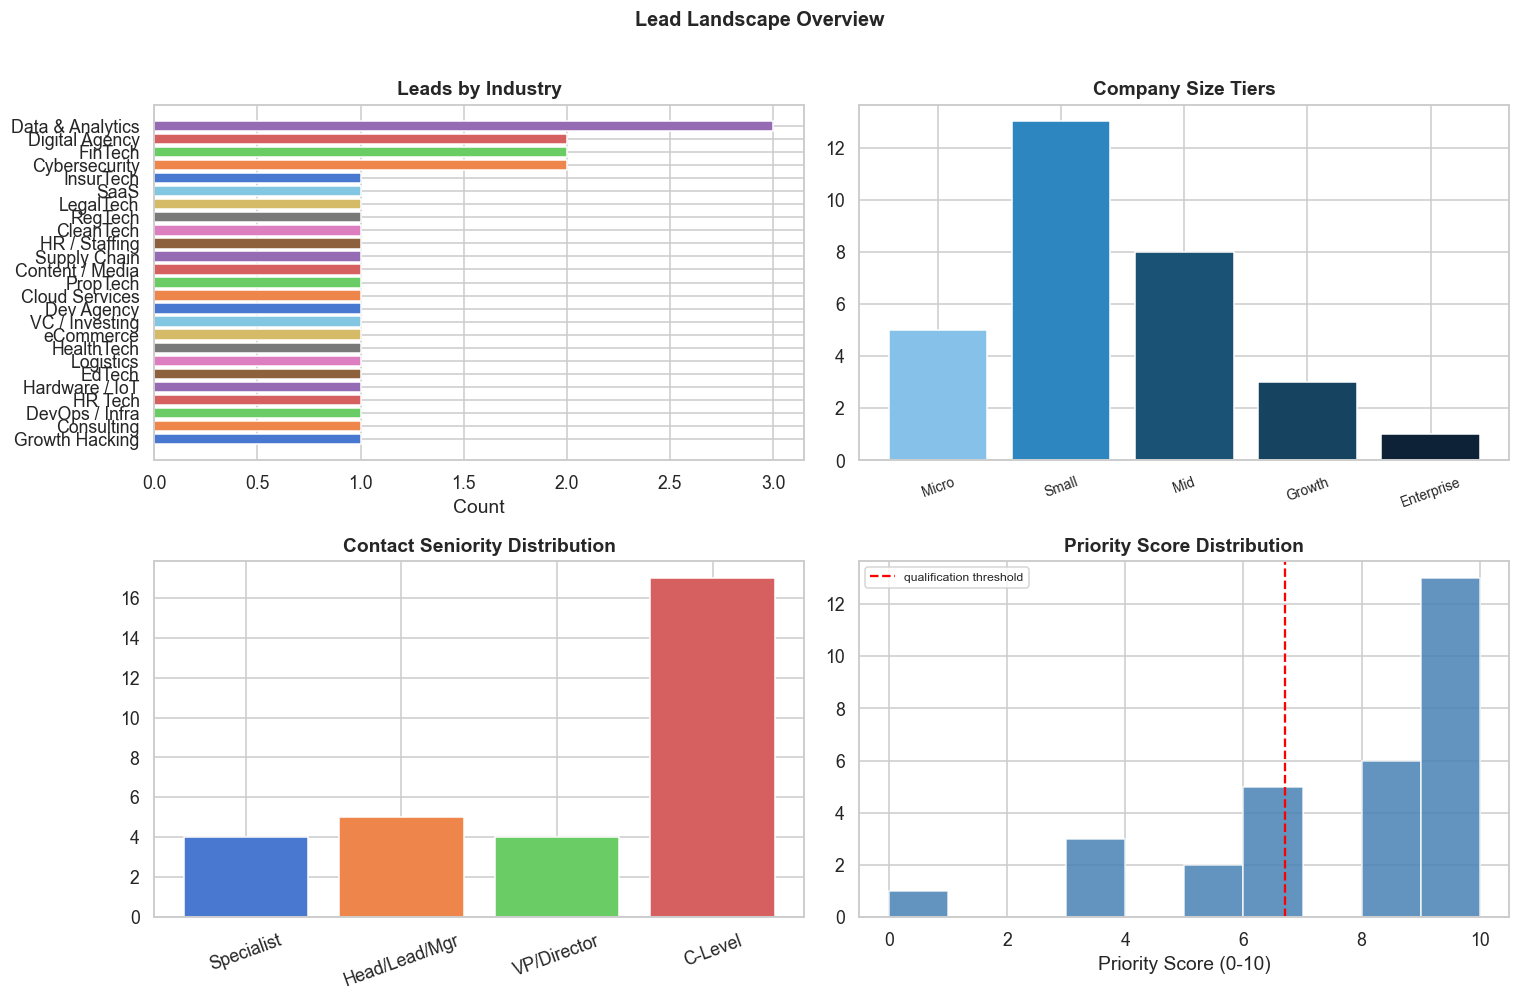

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── leads by industry ───────────────────────────────────────────────────────
ind_counts = df['industry'].value_counts().sort_values()
axes[0,0].barh(ind_counts.index, ind_counts.values,
               color=sns.color_palette('muted', len(ind_counts)))
axes[0,0].set_title('Leads by Industry', fontweight='bold')
axes[0,0].set_xlabel('Count')

# ── company tier distribution ────────────────────────────────────────────────
tier_order = ['Micro  (1-10)','Small  (11-50)',
              'Mid    (51-200)','Growth (201-500)','Enterprise (500+)']
tier_counts = df['company_tier'].value_counts().reindex(tier_order, fill_value=0)
colors = ['#85C1E9','#2E86C1','#1A5276','#154360','#0D2137']
axes[0,1].bar(range(len(tier_counts)), tier_counts.values, color=colors)
axes[0,1].set_xticks(range(len(tier_counts)))
axes[0,1].set_xticklabels([t.split('(')[0].strip() for t in tier_counts.index],
                           rotation=20, fontsize=9)
axes[0,1].set_title('Company Size Tiers', fontweight='bold')

# ── seniority score distribution ─────────────────────────────────────────────
seniority_counts = df['seniority_score'].value_counts().sort_index()
labels = {1:'Specialist', 2:'Senior', 3:'Head/Lead/Mgr', 4:'VP/Director', 5:'C-Level'}
axes[1,0].bar(
    [labels.get(i, str(i)) for i in seniority_counts.index],
    seniority_counts.values,
    color=sns.color_palette('muted', len(seniority_counts))
)
axes[1,0].set_title('Contact Seniority Distribution', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# ── priority score histogram ─────────────────────────────────────────────────
axes[1,1].hist(df['priority_score'], bins=10, color='steelblue', alpha=0.85, edgecolor='white')
axes[1,1].axvline(qualified['priority_score'].min(), color='red',
                  linestyle='--', linewidth=1.5, label='qualification threshold')
axes[1,1].set_title('Priority Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('Priority Score (0-10)')
axes[1,1].legend(fontsize=8)

plt.suptitle('Lead Landscape Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_leads_overview.png', bbox_inches='tight')
plt.show()

## 8. Export Final Lead List

In [11]:
export_cols = [
    'company_name', 'industry', 'location', 'company_tier',
    'website', 'contact_name', 'contact_title', 'contact_email',
    'email_valid', 'seniority_score', 'priority_score', 'industry_match'
]
df['industry_match'] = df['industry'].isin(TARGET_INDUSTRIES)
# full list — all scraped leads
df[export_cols].to_csv('leads_all.csv', index=False)

# qualified list — filtered & ranked
qualified[export_cols].to_csv('leads_enriched.csv', index=False)

print('Saved:')
print(f'  leads_all.csv      — {len(df)} records (full scrape)')
print(f'  leads_enriched.csv — {len(qualified)} records (qualified only)')
print()
print('Final qualified list preview:')
qualified[['company_name','contact_name','contact_title',
           'contact_email','priority_score']].head(10)

Saved:
  leads_all.csv      — 30 records (full scrape)
  leads_enriched.csv — 21 records (qualified only)

Final qualified list preview:


,company_name,contact_name,contact_title,contact_email,priority_score
12,PulseHealth AI,Dr. Aisha Okafor,CEO,aisha.okafor@pulsehealth.ai,10.0
1,BlueRidge Analytics,Mark Thompson,CEO,mark.thompson@blueridge.ai,10.0
28,Axiom Cloud Security,Liam O'Brien,CEO,liam.obrien@axiomcloudsec.com,10.0
26,Trident Compliance,Nathan Brooks,Founder,nathan.brooks@tridentcompliance.io,10.0
25,ArcLight Solar,Emma Johansson,CEO,emma.johansson@arclightsolar.com,10.0
17,Onward Payments,Sophie Laurent,CEO,sophie.laurent@onwardpay.com,10.0
15,Bright Commerce,Carlos Diaz,Founder,carlos.diaz@brightcommerce.co,10.0
14,Helix Cyber,Maria Volkov,CISO,maria.volkov@helixcyber.com,10.0
29,Harbour PropTech,Isabella Russo,Co-Founder,isabella.russo@harbourprop.io,10.0
6,Elevate HR Solutions,Laura Simmons,CEO,laura.simmons@elevatehr.io,10.0


## Summary

This notebook demonstrates the full lead generation workflow:

1. **Scraping** — `requests` fetches the page, `BeautifulSoup` parses the HTML structure
2. **Extraction** — CSS selectors pull structured fields from each card reliably
3. **Cleaning** — employee ranges parsed, emails normalised, location split into city/state
4. **Enrichment** — three derived signals (company tier, seniority score, email validity)
   combined into a single priority score
5. **Filtering** — qualification criteria applied to focus outreach on highest-value leads
6. **Export** — two CSVs: full scrape and qualified-only list

> **Scaling up:** for multi-page directories, wrap `fetch_page()` in a loop with
> pagination logic and `time.sleep(REQUEST_DELAY)` between requests.
> For JavaScript-rendered pages, swap `requests` for `playwright` or `selenium`
> while keeping the same BeautifulSoup parsing layer.